# Covariance And Corelation,

### Covariance

    Covariance is a statistical measure that describes the direction of the relationship between two variables.

    It indicates whether two variables tend to increase together, decrease together, or move in opposite directions.

    Unlike measures of central tendency and dispersion, covariance measures the relationship between two variables rather than describing a single variable.

    Covariance is widely used in data analysis, finance, machine learning, and predictive modeling.

## Types of Covariance And Corelation

### Positive Covariance And Positive Corelation

    Both variables move in the same direction.

    When one variable increases, the other variable also tends to increase.

    Similarly, when one variable decreases, the other variable also tends to decrease.

    Example:
        - Advertisement Cost and Sales
        - Study Hours and Exam Scores



### Negative Covariance And Nagative Corelation
    Both variables move in opposite directions.

    When one variable increases, the other variable tends to decrease.

    Example:
        - Product Price and Customer Demand
        - Speed and Travel Time

### Zero Covariance && Zero Corelation

    There is no linear relationship between the two variables.

    A change in one variable does not indicate any consistent change in the other variable.

    Example:

        - Shoe Size and Monthly Salary

### Formula
    The sample covariance between two variables is

$$
Cov(X,Y)=
\frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}
{n-1}
$$

| Symbol | Meaning |
|--------|---------|
| $x_i$ | Observation of variable X |
| $y_i$ | Observation of variable Y |
| $\bar{x}$ | Mean of variable X |
| $\bar{y}$ | Mean of variable Y |
| $n$ | Number of observations |

In [2]:
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as sts 

In [4]:
Business = pd.DataFrame({

    "Advertising_Cost":[
        10,15,20,25,30,
        35,40,45,50,55
    ],

    "Sales":[
        100,120,135,155,175,
        190,210,225,245,265
    ]

})

Business.head()

,Advertising_Cost,Sales
0,10,100
1,15,120
2,20,135
3,25,155
4,30,175


### 5 Number Summury In Stats

In [7]:
Business.describe().round(2)

,Advertising_Cost,Sales
count,10.00,10.00
mean,32.50,182.00
std,15.14,54.88
min,10.00,100.00
25%,21.25,140.00
50%,32.50,182.50
75%,43.75,221.25
max,55.00,265.00


In [11]:
mean_x = Business["Advertising_Cost"].mean()

mean_y = Business["Sales"].mean()

print(f"Mean of Advertising Cost(X): {mean_x}")

print(f"Mean of Sales (Y): {mean_y}")

Mean of Advertising Cost(X): 32.5
Mean of Sales (Y): 182.0


In [9]:
Business["X - Mean"] = Business["Advertising_Cost"] - mean_x

Business["Y - Mean"] = Business["Sales"] - mean_y

Business

,Advertising_Cost,Sales,X - Mean,Y - Mean
0,10,100,-22.5,-82.0
1,15,120,-17.5,-62.0
2,20,135,-12.5,-47.0
3,25,155,-7.5,-27.0
4,30,175,-2.5,-7.0
5,35,190,2.5,8.0
6,40,210,7.5,28.0
7,45,225,12.5,43.0
8,50,245,17.5,63.0
9,55,265,22.5,83.0


In [10]:
Business["Product"] = (

    Business["X - Mean"] *

    Business["Y - Mean"]

)

Business

,Advertising_Cost,Sales,X - Mean,Y - Mean,Product
0,10,100,-22.5,-82.0,1845.0
1,15,120,-17.5,-62.0,1085.0
2,20,135,-12.5,-47.0,587.5
3,25,155,-7.5,-27.0,202.5
4,30,175,-2.5,-7.0,17.5
5,35,190,2.5,8.0,20.0
6,40,210,7.5,28.0,210.0
7,45,225,12.5,43.0,537.5
8,50,245,17.5,63.0,1102.5
9,55,265,22.5,83.0,1867.5


In [12]:
sum_product = Business["Product"].sum()

n = len(Business)

covariance = sum_product / (n - 1)

print(f"Sample Covariance : {covariance:.2f}")

Sample Covariance : 830.56


### Using Pandas 

In [13]:
Business[["Advertising_Cost","Sales"]].cov()

,Advertising_Cost,Sales
Advertising_Cost,229.166667,830.555556
Sales,830.555556,3012.222222


### Using Numpy

In [17]:
np.cov(Business['Advertising_Cost'],
      Business['Sales']
      
      )

array([[ 229.16666667,  830.55555556],
       [ 830.55555556, 3012.22222222]])

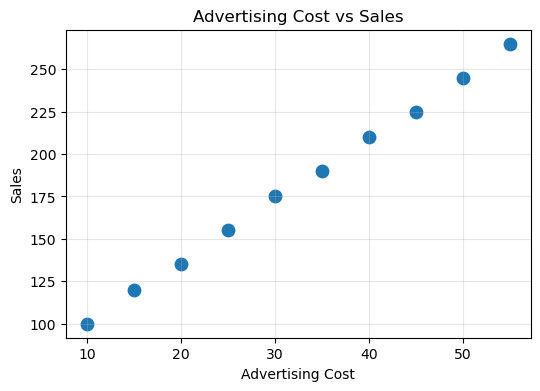

In [24]:

plt.figure(figsize=(6,4))

plt.scatter(

    Business["Advertising_Cost"],

    Business["Sales"],

    s=80

)

plt.title("Advertising Cost vs Sales")

plt.xlabel("Advertising Cost")

plt.ylabel("Sales")

plt.grid(alpha=0.3)

plt.show()

### Covariance of a Variable with Itself
    The covariance of a variable with itself is equal to its variance.

    Mathematically,

$$
Cov(X,X)=Var(X)
$$

    This is because both variables are identical, so every observation moves exactly with itself.

    Therefore, the covariance is always equal to the variance of that variable.


- NumPy var() → Population variance by default (ddof=0).
- Pandas var() → Sample variance by default (ddof=1).
- NumPy cov() → Sample covariance by default (ddof=1).

In [42]:
x = np.array([10,20,30,40,50])

print("Covariance:",np.cov(x,ddof=0))

Covariance: 200.0


In [44]:
x = np.array([10,20,30,40,50])

print("Variance:-",np.var(x))

Variance:- 200.0


### Disadvantages of Covariance
    - The magnitude of covariance depends on the units of measurement.
    - Covariance only indicates the direction of the relationship, not its strength.
    - Covariance values cannot be compared across different datasets with different units or scales.
    - A large covariance value does not necessarily indicate a strong relationship.
    - It is sensitive to extreme values (outliers), which can significantly affect the result.

    Because of these limitations, correlation is generally preferred over covariance when measuring the relationship between variables.

# Correlation

    Correlation is a statistical measure that describes both the direction and the strength of the linear relationship between two variables.

    Unlike covariance, correlation is a standardized measure whose values always lie between -1 and +1.

    Because it is independent of the units of measurement, correlation is widely used in data analysis, business intelligence, finance, economics, and machine learning.

### Correlation Coefficient
    The correlation coefficient is represented by r (sample correlation) or p (population correlation).

    Its value always lies between

$$
-1 \le r \le +1
$$

    The sign indicates the direction of the relationship, while the magnitude indicates its strength.

### Formula
    The Pearson Correlation Coefficient is calculated using

$$
r=
\frac{\sum (x_i-\bar{x})(y_i-\bar{y})}
{\sqrt{\sum(x_i-\bar{x})^2\sum(y_i-\bar{y})^2}}
$$

| Symbol | Meaning |
|--------|---------|
| $x_i$ | Observation of variable X |
| $y_i$ | Observation of variable Y |
| $\bar{x}$ | Mean of variable X |
| $\bar{y}$ | Mean of variable Y |
| $r$ | Pearson Correlation Coefficient |

### Interpretation of Correlation Coefficient

| Correlation (r) | Interpretation |
|----------------:|----------------|
| +1.00 | Perfect Positive Correlation |
| +0.70 to +0.99 | Strong Positive Correlation |
| +0.30 to +0.69 | Moderate Positive Correlation |
| +0.01 to +0.29 | Weak Positive Correlation |
| 0 | No Linear Correlation |
| -0.01 to -0.29 | Weak Negative Correlation |
| -0.30 to -0.69 | Moderate Negative Correlation |
| -0.70 to -0.99 | Strong Negative Correlation |
| -1.00 | Perfect Negative Correlation |

In [20]:
Business[["Advertising_Cost","Sales"]].corr()

,Advertising_Cost,Sales
Advertising_Cost,1.000000,0.999653
Sales,0.999653,1.000000


In [25]:
correlation = Business["Advertising_Cost"].corr(
    Business["Sales"]
)

print(f"Pearson Correlation : {correlation:.3f}")

Pearson Correlation : 1.000


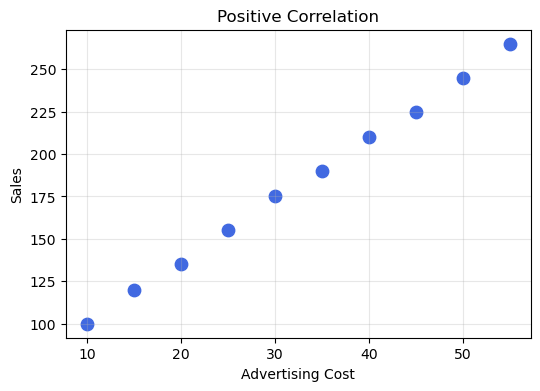

In [27]:
plt.figure(figsize=(6,4))

plt.scatter(

    Business["Advertising_Cost"],

    Business["Sales"],

    s=80,

    color="royalblue"

)

plt.title("Positive Correlation")

plt.xlabel("Advertising Cost")

plt.ylabel("Sales")

plt.grid(alpha=.3)

plt.show()

In [28]:
Negative = pd.DataFrame({

    "Price":[
        10,20,30,40,50,60
    ],

    "Demand":[
        100,90,80,70,60,50
    ]

})

Negative

,Price,Demand
0,10,100
1,20,90
2,30,80
3,40,70
4,50,60
5,60,50


In [29]:
Negative.corr()

,Price,Demand
Price,1.0,-1.0
Demand,-1.0,1.0


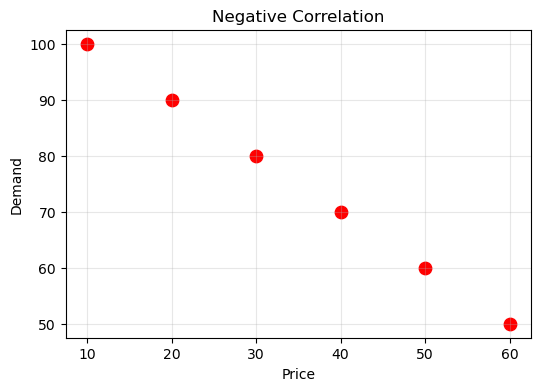

In [32]:
plt.figure(figsize=(6,4))

plt.scatter(Negative["Price"],Negative["Demand"],s=80,color="red"
           
           )

plt.title("Negative Correlation")

plt.xlabel("Price")

plt.ylabel("Demand")

plt.grid(alpha=.3)

plt.show()

In [33]:
np.random.seed(42)

No_Correlation = pd.DataFrame({

    "X":np.random.randint(10,100,40),

    "Y":np.random.randint(10,100,40)

})

No_Correlation.head()

,X,Y
0,61,12
1,24,60
2,81,16
3,70,30
4,30,82


In [34]:
No_Correlation.corr()

,X,Y
X,1.000000,-0.049873
Y,-0.049873,1.000000


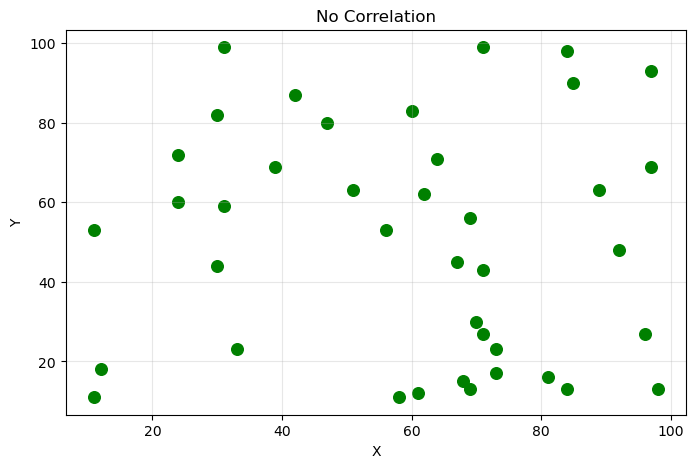

In [36]:
plt.figure(figsize=(8,5))

plt.scatter(No_Correlation["X"],
            No_Correlation["Y"],
            s=70,
            color="green"
                )

plt.title("No Correlation")

plt.xlabel("X")

plt.ylabel("Y")

plt.grid(alpha=.3)

plt.show()

# Covariance Matrix
    A Covariance Matrix is a square matrix that shows the covariance between every pair of variables in a dataset.

    The diagonal elements of the matrix represent the variance of each variable because the covariance of a variable with itself is equal to its variance.

    The off-diagonal elements represent the covariance between different variables.

In [45]:
Business.corr()

,Advertising_Cost,Sales,X - Mean,Y - Mean,Product
Advertising_Cost,1.000000,0.999653,1.000000,0.999653,0.002619
Sales,0.999653,1.000000,0.999653,1.000000,0.005346
X - Mean,1.000000,0.999653,1.000000,0.999653,0.002619
Y - Mean,0.999653,1.000000,0.999653,1.000000,0.005346
Product,0.002619,0.005346,0.002619,0.005346,1.000000


### Interpretation
    The diagonal values represent the variance of each variable.
    
        For example,
            - Cov(Advertising Cost, Advertising Cost) = Variance of Advertising Cost
            - Cov(Sales, Sales) = Variance of Sales

    The off-diagonal values represent the covariance between different variables.

        If the off-diagonal value is positive, both variables tend to move in the same direction.

        If it is negative, they tend to move in opposite directions.

### Pearson Correlation
    Pearson Correlation measures the strength and direction of the linear relationship between two continuous variables.

    It is the most commonly used correlation coefficient in statistics and data analysis.

    Pearson Correlation assumes that:
        - Both variables are continuous.
        - The relationship is linear.
        - The data does not contain significant outliers.

In [51]:
p=Business["Advertising_Cost"].corr(

    Business["Sales"],

    method="pearson"

)
print("Pearson:-",p)

Pearson:- 0.9996534279780763


### Spearman Correlation
    Spearman Correlation measures the strength and direction of a monotonic relationship between two variables.

    Instead of using the original values, it uses the ranks of the observations.

    Spearman Correlation is preferred when:
        - Data contains outliers.
        - Data is not normally distributed.
        - The relationship is monotonic but not necessarily linear.

In [50]:
s=Business["Advertising_Cost"].corr(

    Business["Sales"],

    method="spearman"

)
print("Spearman:-",s)

Spearman:- 0.9999999999999999


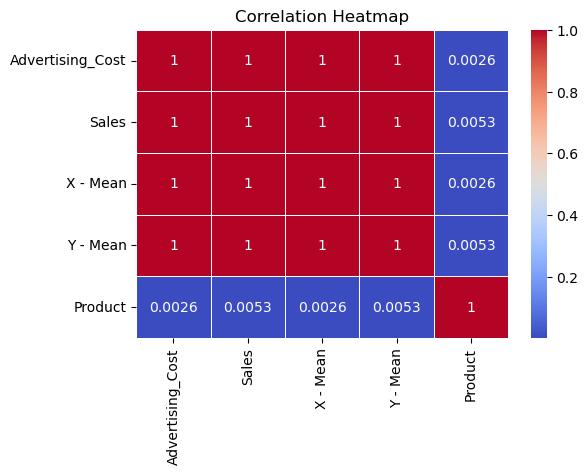

In [52]:
plt.figure(figsize=(6,4))

sns.heatmap(

    Business.corr(),

    annot=True,

    cmap="coolwarm",

    linewidths=0.5

)

plt.title("Correlation Heatmap")

plt.show()

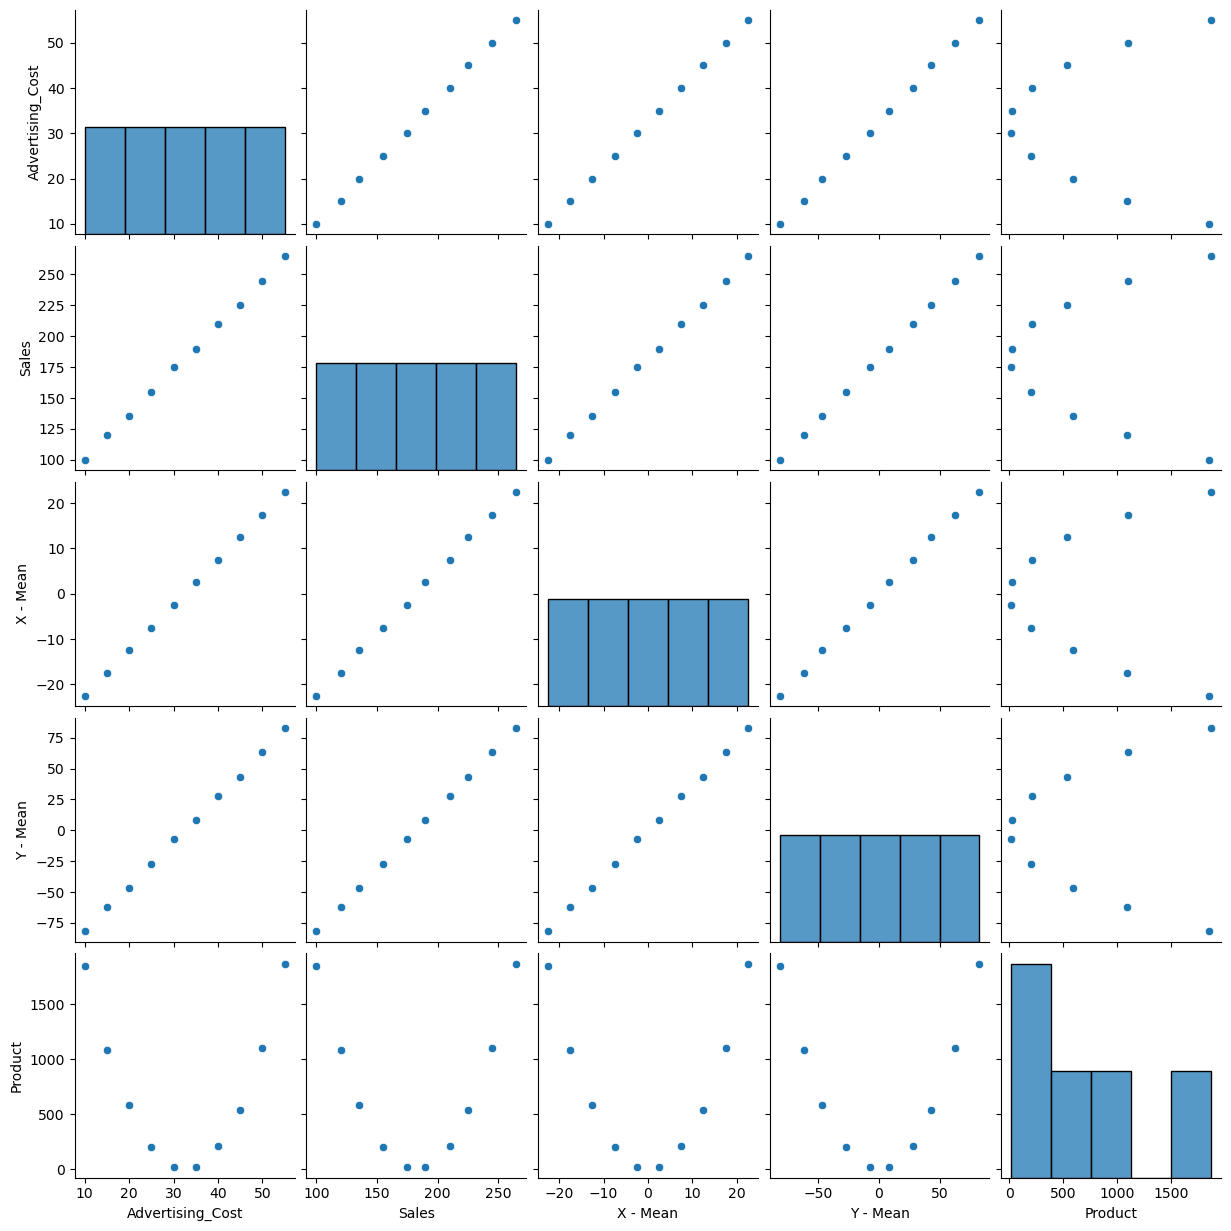

In [59]:

sns.pairplot(Business)

plt.show()